In [ ]:
# Data Analysis & Data Viz
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import seaborn as sns

# NLP
import re
import nltk
! pip install contractions
import contractions
from nltk.corpus import wordnet
from nltk import pos_tag
from nltk.corpus import stopwords
from wordcloud import WordCloud
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')
nltk.download('punkt')

# Gensim
import gensim
from gensim.utils import simple_preprocess
from gensim.parsing.preprocessing import STOPWORDS
import gensim.corpora as corpora
from gensim.models import LdaModel
from pprint import pprint
from gensim.models import CoherenceModel
! pip install pyLDAvis
import pyLDAvis
import pyLDAvis.gensim_models
import pickle

# Machine Learning
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix as cm
from sklearn.naive_bayes import MultinomialNB

# Warnings
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category = DeprecationWarning)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 289.9/289.9 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 110.7/110.7 kB 4.7 MB/s eta 0:00:00


[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 14.7 MB/s eta 0:00:00


In [ ]:
# Load the datasets from the url
!wget https://proai-datasets.s3.eu-west-3.amazonaws.com/fake_news.zip

# Unzip the two dataset
!unzip fake_news.zip

--2024-10-20 18:10:10--  https://proai-datasets.s3.eu-west-3.amazonaws.com/fake_news.zip
Resolving proai-datasets.s3.eu-west-3.amazonaws.com (proai-datasets.s3.eu-west-3.amazonaws.com)... 52.95.154.86, 52.95.156.94
Connecting to proai-datasets.s3.eu-west-3.amazonaws.com (proai-datasets.s3.eu-west-3.amazonaws.com)|52.95.154.86|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 42975911 (41M) [application/zip]
Saving to: ‘fake_news.zip’

fake_news.zip       100%[===================>]  40.98M  18.9MB/s    in 2.2s    

2024-10-20 18:10:13 (18.9 MB/s) - ‘fake_news.zip’ saved [42975911/42975911]

Archive:  fake_news.zip
  inflating: Fake.csv                
  inflating: True.csv                


In [ ]:
# Load the two dataset
df_fake_news = pd.read_csv('Fake.csv')
df_true_news = pd.read_csv('True.csv')

In [ ]:
# General info fake news
df_fake_news.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23481 entries, 0 to 23480
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    23481 non-null  object
 1   text     23481 non-null  object
 2   subject  23481 non-null  object
 3   date     23481 non-null  object
dtypes: object(4)
memory usage: 733.9+ KB


In [ ]:
# General info true news
df_true_news.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21417 entries, 0 to 21416
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    21417 non-null  object
 1   text     21417 non-null  object
 2   subject  21417 non-null  object
 3   date     21417 non-null  object
dtypes: object(4)
memory usage: 669.4+ KB


Both datasets consist of textual data (object) across 4 columns: title, text, subject, and date. The dataset on fake news contains 23,481 entries, while the other comprises 21,417 entries. Both datasets exhibit no missing values and are substantially similar in size.

In [ ]:
# Create a new column to preserve the typology of news
df_fake_news['type_news'] = 'fake' # 0
df_true_news['type_news'] = 'true' # 1

In [ ]:
# Merge the two dataset in a new one
df_news = pd.concat([df_fake_news, df_true_news], ignore_index=True)

# Check new dataset sample
df_news.sample(10)

,title,text,subject,date,type_news
942,"Chuck Todd Takes On Trump’s Media Attacks, Th...",Donald Trump s attacks on the free press conti...,News,"July 3, 2017",fake
37981,"The boss is dead but the mafia lives, magistra...",ROME/PALERMO (Reuters) - The death of Sicilian...,worldnews,"November 17, 2017",true
15970,THE PURGE: NYC Mayor De Blasio to Review ‘All ...,THE PURGE CONTINUES THE NYC MAYOR has just ope...,Government News,"Aug 16, 2017",fake
32680,S&P ratchets up pressure on Alaska over budget,(Reuters) - S&P Global Ratings warned on Thurs...,politicsNews,"June 10, 2016",true
38576,Indonesia warns of tough response after Papuan...,JAKARTA (Reuters) - Indonesia s military said ...,worldnews,"November 10, 2017",true
11407,WOOHOO! NEVER TRUMPER Tells Why He’s Jumpin’ o...,When you bring #NeverTrumper @greggutfeld on-b...,politics,"Mar 14, 2017",fake
43812,U.S. officials say about 5-6 million customers...,WASHINGTON (Reuters) - Five million to 6 milli...,worldnews,"September 12, 2017",true
25824,Tillerson to press China and ASEAN states on N...,WASHINGTON (Reuters) - U.S. Secretary of State...,politicsNews,"August 2, 2017",true
8021,"Cliven Bundy Indicted For Assault, Faces Life...",If you missed it in all the kerfluffle over th...,News,"February 18, 2016",fake
9773,FRANCE’S INTERIOR MINISTER Makes INSANE Statem...,A man shouting Allahu Akbar has stabbed two ...,politics,"Oct 1, 2017",fake


In [ ]:
# Check again info the two merged datasets
df_news.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44898 entries, 0 to 44897
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   title      44898 non-null  object
 1   text       44898 non-null  object
 2   subject    44898 non-null  object
 3   date       44898 non-null  object
 4   type_news  44898 non-null  object
dtypes: object(5)
memory usage: 1.7+ MB


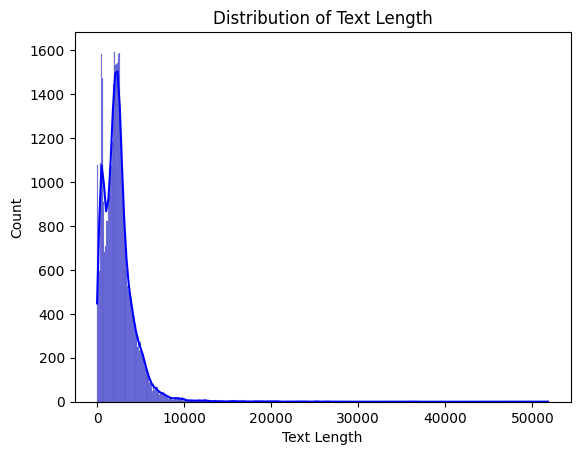

In [ ]:
# Check lenght text
df_news['length_text'] = df_news['text'].apply(len)
sns.histplot(df_news['length_text'], color="blue", kde=True)
plt.title('Distribution of Text Length')
plt.xlabel('Text Length')
plt.show()

The distribution of text length appears to be right-skewed, meaning that most the texts are relatively short, but there are a few longer texts.



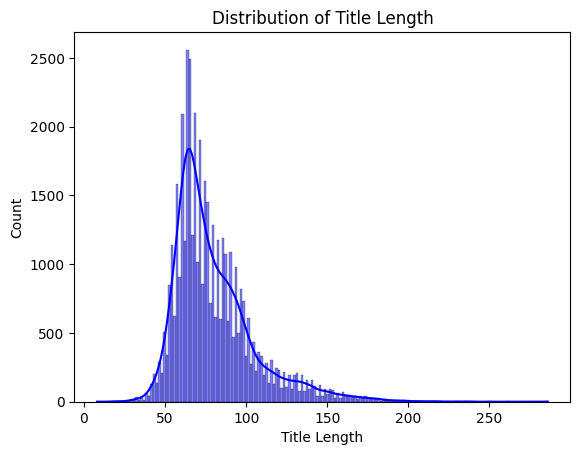

In [ ]:
# Check length title
df_news['length_title'] = df_news['title'].apply(len)
sns.histplot(df_news['length_title'], color="blue", kde=True)
plt.title('Distribution of Title Length')
plt.xlabel('Title Length')
plt.show()

The title lenght has also a right-skewed distribution, meaning most of the titles have shorter lengths, and only a few titles are longer.

# DATA PREPROCESSING & CLEANING

In [ ]:
# Create a copy of the datset for cleaning operations
df_news_copy = df_news.copy()

In [ ]:
# Check for eventual blank spaces
blanks = []

for row in df_news_copy.itertuples():
    if isinstance(row.text, str):
        if row.text.strip() == "":
            blanks.append(row.Index)

# Print results
print(len(blanks), 'blanks: ', blanks)

631 blanks:  [10923, 11041, 11190, 11225, 11236, 11241, 11247, 11249, 11267, 11268, 11283, 11284, 11285, 11289, 11290, 11292, 11295, 11296, 11301, 11303, 11304, 11305, 11309, 11314, 11317, 11319, 11322, 11330, 11334, 11335, 11340, 11343, 11348, 11351, 11352, 11357, 11371, 11373, 11374, 11382, 11397, 11402, 11403, 11409, 11410, 11412, 11415, 11419, 11421, 11427, 11431, 11432, 11440, 11448, 11450, 11453, 11462, 11464, 11465, 11472, 11473, 11475, 11478, 11489, 11491, 11493, 11494, 11501, 11505, 11507, 11520, 11531, 11532, 11533, 11538, 11542, 11547, 11549, 11551, 11559, 11563, 11581, 11585, 11589, 11590, 11614, 11624, 11625, 11627, 11631, 11636, 11637, 11643, 11650, 11658, 11661, 11672, 11679, 11681, 11684, 11686, 11688, 11692, 11708, 11718, 11729, 11739, 11753, 11765, 11768, 11777, 11782, 11786, 11788, 11792, 11793, 11803, 11806, 11813, 11821, 11831, 11832, 11841, 11844, 11848, 11854, 11858, 11860, 11863, 11866, 11872, 11874, 11875, 11879, 11881, 11884, 11889, 11893, 11900, 11904, 11906,

In [ ]:
# Remove 631 blank spaces
df_news_copy.drop(blanks, inplace=True)

In [ ]:
# Remove 'data' column from the copied dataset
df_news_copy.drop(['date'], axis=1, inplace=True) # not useful for the analysis

In [ ]:
# Drop duplicates
df_news_copy.drop_duplicates(inplace=True)

In [ ]:
# Check unique values in the 'subject' column
df_news_copy['subject'].unique()

array(['News', 'politics', 'Government News', 'left-news', 'US_News',
       'Middle-east', 'politicsNews', 'worldnews'], dtype=object)

In [ ]:
# Modify names for consistency and better clarity
df_news_copy['subject'] = df_news_copy['subject'].replace({'left-news': 'Left News',
                                                  'politics': 'Politics News',
                                                  'politicsNews': 'Politics News',
                                                  'US_News': 'US News',
                                                  'Middle-east': 'Middle-East News',
                                                  'worldnews': 'World News',
                                                  'News': 'General News'})

In [ ]:
# Check the first document before cleaning
df_news_copy['text'][5]

'The number of cases of cops brutalizing and killing people of color seems to see no end. Now, we have another case that needs to be shared far and wide. An Alabama woman by the name of Angela Williams shared a graphic photo of her son, lying in a hospital bed with a beaten and fractured face, on Facebook. It needs to be shared far and wide, because this is unacceptable.It is unclear why Williams  son was in police custody or what sort of altercation resulted in his arrest, but when you see the photo you will realize that these details matter not. Cops are not supposed to beat and brutalize those in their custody. In the post you are about to see, Ms. Williams expresses her hope that the cops had their body cameras on while they were beating her son, but I think we all know that there will be some kind of convenient  malfunction  to explain away the lack of existence of dash or body camera footage of what was clearly a brutal beating. Hell, it could even be described as attempted murde

In [ ]:
# Check first title before cleaning
df_news_copy['title'][0]

' Donald Trump Sends Out Embarrassing New Year’s Eve Message; This is Disturbing'

In [ ]:
# Initialize the lemmatizer
lemmatizer = WordNetLemmatizer()

# Function to map POS tags from nltk to WordNet POS
def get_part_of_speech(tag):
    tag_dict = {'J': wordnet.ADJ,   # Adjectives
                'N': wordnet.NOUN,  # Nouns
                'V': wordnet.VERB,  # Verbs
                'R': wordnet.ADV}   # Adverbs

    return tag_dict.get(tag[0].upper(), wordnet.NOUN)

In [ ]:
# Function to clean and lemmatize text
def preprocess_text(texts):
    cleaned_texts = []

    for text in texts:
        # Expand contractions (e.g., "can't" will become "cannot")
        text = contractions.fix(text)

        # Remove URLs, mentions, and hashtags
        text = re.sub(r'http\S+|www\S+|https\S+', '', str(text), flags=re.MULTILINE)  # URLs
        text = re.sub(r'@\w+', '', text)  # Mentions
        text = re.sub(r'#\w+', '', text)  # Hashtags

        # Tokenize and remove stopwords using Gensim (topic modeling)
        words = gensim.utils.simple_preprocess(text, deacc=True)
        filtered_words = [word for word in words if word not in STOPWORDS and len(word) > 5]

        # Lemmatize with POS tagging (otherwise it will classfiy all tokens as NOUNS)
        lemmatized_words = [lemmatizer.lemmatize(word, get_part_of_speech(pos_tag([word])[0][1])) for word in filtered_words]

        # Append the lemmatized words to the list
        cleaned_texts.append(lemmatized_words)

    return cleaned_texts

In [ ]:
# Apply function to clean text
df_news_copy['cleaned_text'] = preprocess_text(df_news_copy['text'])

In [ ]:
# Check first document to see list of tokens
df_news_copy['cleaned_text'][0]

['donald',
 'couldn',
 'american',
 'instead',
 'enemy',
 'hater',
 'dishonest',
 'reality',
 'couldn',
 'country',
 'rapidly',
 'strong',
 'smarter',
 'friend',
 'supporter',
 'enemy',
 'hater',
 'dishonest',
 'healthy',
 'president',
 'tweet',
 'america',
 'country',
 'rapidly',
 'strong',
 'smarter',
 'friend',
 'supporter',
 'enemy',
 'hater',
 'dishonest',
 'healthy',
 'america',
 'donald',
 'december',
 'expect',
 'president',
 'greet',
 'despicable',
 'infantile',
 'gibberish',
 'decency',
 'gutter',
 'american',
 'citizen',
 'bishop',
 'talbert',
 'december',
 'calvin',
 'december',
 'impeachment',
 'america',
 'accept',
 'regain',
 'control',
 'congress',
 'miranda',
 'december',
 'include',
 'people',
 'wonder',
 'sandoval',
 'december',
 'hater',
 'marlene',
 'december',
 'pollitt',
 'december',
 'include',
 'enemy',
 'fought',
 'donald',
 'december',
 'direct',
 'message',
 'enemy',
 'hater',
 'easter',
 'thanksgiving',
 'anniversary',
 'twitter',
 'daniel',
 'december',
 '

In [ ]:
# Function to clean and lemmatize titles
def preprocess_title(titles):
    cleaned_titles = []

    for title in titles:
        # Expand contractions (e.g., "can't" will become "cannot")
        title = contractions.fix(title)

        # Tokenize and remove stopwords using Gensim (topic modeling)
        words = gensim.utils.simple_preprocess(title, deacc=True)
        filtered_words = [word for word in words if word not in STOPWORDS and len(word) > 3]

        # Lemmatize with POS tagging (otherwise it will consider all tokens as nouns)
        lemmatized_words = [lemmatizer.lemmatize(word, get_part_of_speech(pos_tag([word])[0][1])) for word in filtered_words]

        # Append the lemmatized words to the list
        cleaned_titles.append(lemmatized_words)

    return cleaned_titles

In [ ]:
# Apply function to clean title
df_news_copy['cleaned_title'] = preprocess_title(df_news_copy['title'])

In [ ]:
# Check result
df_news_copy['cleaned_title'][0]

['donald', 'trump', 'sends', 'embarrass', 'year', 'message', 'disturb']

In [ ]:
# Drop 'title' and 'text' column
df_news_copy.drop(['title', 'text'], axis=1, inplace=True)

In [ ]:
# Check cleaned dataset
df_news_copy.sample(10)

,subject,type_news,length_text,length_title,cleaned_text,cleaned_title
24055,Politics News,true,2499,54,"[washington, reuters, united, state, special, ...","[protect, status, haitian, july]"
14933,Politics News,fake,1026,92,"[single, aspect, mizzou, controversy, proven, ...","[mizzou, baby, complain, paris, terror, traged..."
10072,Politics News,fake,2288,102,"[parent, decide, population, consider, transge...","[twist, liberal, kindergarten, teacher, allows..."
29252,Politics News,true,2849,47,"[washington, reuters, president, donald, open,...","[trump, blast, medium, black, history, month, ..."
16672,Government News,fake,416,57,"[answer, recover, director, press, end, straig...","[director, finally, bring, boom, hillary]"
21151,Left News,fake,1501,26,"[question, protect, attorney, general, loretta...","[hillary, indict]"
13996,Politics News,fake,230,98,"[tow, democrat, member, switch, allegiance, re...","[yikes, year, hillary, lie, driven, know, demo..."
39638,World News,true,1622,69,"[beijing, reuters, understands, spanish, gover...","[china, reiterates, support, spanish, governme..."
33376,Politics News,true,585,72,"[washington, reuters, democratic, presidential...","[clinton, say, obama, immigration, statement]"
44507,World News,true,779,77,"[moscow, reuters, russian, serviceman, kill, p...","[russian, soldier, kill, shell, syria, deir, p..."


In [ ]:
# Save cleaned dataset
df_news_copy.to_csv('cleaned_dataset.csv', index=False)

# NLP ANALYSIS

###What is the most frequent category of fake news?

In [ ]:
# Calculate distribution of 'subject' divided by news type
count_distribution = df_news_copy.groupby('type_news')['subject'].value_counts()

# Calculate proportions news_type
proportion_distribution = df_news_copy.groupby('type_news')['subject'].value_counts(normalize=True)

# Combine results in a dataframe
combined_distribution = pd.DataFrame({'count': count_distribution,
                                      'proportion': proportion_distribution}).reset_index()

# Filter data only for fake news
fake_news = combined_distribution[combined_distribution['type_news'] == 'fake']

# Print results
print(fake_news[['subject', 'count','proportion']])

            subject  count  proportion
0      General News   9050    0.396113
1     Politics News   6430    0.281437
2         Left News   4308    0.188559
3   Government News   1498    0.065567
4           US News    783    0.034271
5  Middle-East News    778    0.034053


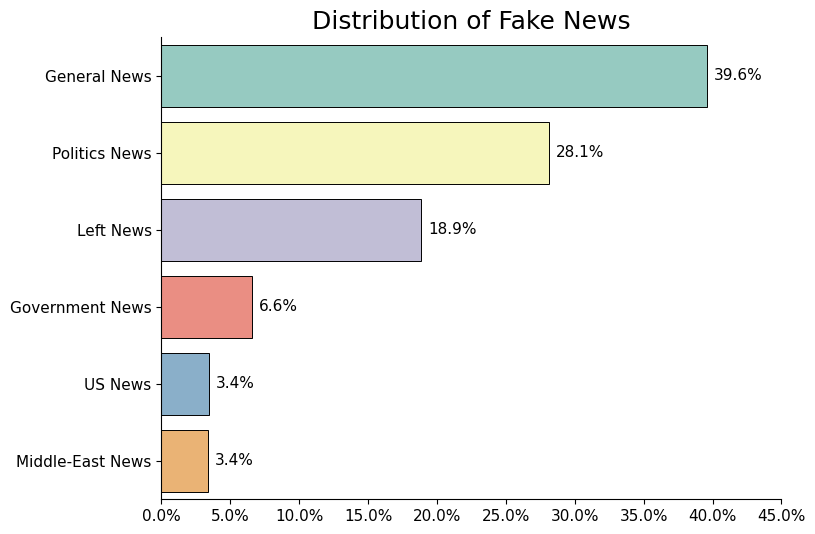

In [ ]:
# Create plot
plt.figure(figsize=(8, 6))
bar_plot = sns.barplot(x='proportion',
                       y='subject',
                       data= fake_news,
                       palette='Set3',
                       hue='subject',
                       edgecolor='black',
                       linewidth=0.7)

# Add percentages to the bars
for index, value in enumerate(fake_news['proportion']):
    plt.text(value + 0.005, index, f'{value:.1%}', va='center', ha='left', fontsize=11)

# Add percentages to the x-axis
plt.gca().xaxis.set_major_formatter(PercentFormatter(1))
plt.xlim(0, 0.45)

# Final personalizations
sns.despine()
plt.title('Distribution of Fake News', fontsize=18)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.xlabel('')
plt.ylabel('')
plt.show()

The barplot indicates that the majority of fake news falls under the category of General News (39.6%). This implies that it is often challenging to identify the precise topic to which these documents belong. Following this, political news accounts for 28.2%, while left-leaning news makes up 18.9% of the total. Government News (6.6%), US News (3.4%) and Middle-East News (3.4%) occur less frequently.

### What are the topics most prone to be fake within each category?

In [ ]:
# Select fake news divided by 'subject' (category)
general_fake = df_news_copy[(df_news_copy['type_news'] == 'fake') & (df_news_copy['subject'] == 'General News')]['cleaned_text']
politics_fake = df_news_copy[(df_news_copy['type_news'] == 'fake') & (df_news_copy['subject'] == 'Politics News')]['cleaned_text']
left_fake = df_news_copy[(df_news_copy['type_news'] == 'fake') & (df_news_copy['subject'] == 'Left News')]['cleaned_text']
government_fake = df_news_copy[(df_news_copy['type_news'] == 'fake') & (df_news_copy['subject'] == 'Government News')]['cleaned_text']
us_fake = df_news_copy[(df_news_copy['type_news'] == 'fake') & (df_news_copy['subject'] == 'US News')]['cleaned_text']
middleeast_fake = df_news_copy[(df_news_copy['type_news'] == 'fake') & (df_news_copy['subject'] == 'Middle-East News')]['cleaned_text']

In [ ]:
# Function to find topics with LDA model
def topic_modeling(data, num_topics, passes=10, random_state=42, chunksize=2000):

    # 1) Create dictionary and corpus
    dictionary = corpora.Dictionary(data)
    corpus = [dictionary.doc2bow(text) for text in data]

    # 2) LDA model
    lda_model_multicore = gensim.models.LdaMulticore(corpus=corpus,
                                                     id2word=dictionary,
                                                     num_topics=num_topics,
                                                     passes=passes,
                                                     random_state=random_state,
                                                     chunksize=chunksize,
                                                     per_word_topics=True)

    # 3) Sort topics by the total weight assigned to them across documents
    topics = lda_model_multicore.show_topics(formatted=False)
    topics_sorted = sorted(topics, key=lambda x: x[0])

    for i, (topic_id, topic_words) in enumerate(topics_sorted, start=1):
        print(f"Topic {i}: {topic_words}")

    # 4) Calculate Coherence Score
    coherence_model_lda = CoherenceModel(model=lda_model_multicore,
                                         texts=data,
                                         dictionary=dictionary,
                                         coherence='c_v')
    coherence_lda = coherence_model_lda.get_coherence()
    print(f'Coherence Score: {coherence_lda:.2f}')

    # 5) Visualize topics with pyLDAvis
    vis = pyLDAvis.gensim_models.prepare(lda_model_multicore, corpus, dictionary)

    return lda_model_multicore, vis

In [ ]:
# General News
lda_model_fake_news, vis = topic_modeling(general_fake, 7)

# Display the visualization
pyLDAvis.display(vis)

Topic 1: [('police', 0.014091505), ('people', 0.011974186), ('school', 0.008769941), ('officer', 0.007336175), ('family', 0.0064361603), ('feature', 0.0064090216), ('child', 0.0055704555), ('student', 0.005546093), ('violence', 0.004743739), ('accord', 0.0045441478)]
Topic 2: [('republican', 0.020892713), ('people', 0.015873132), ('american', 0.014541427), ('million', 0.011891326), ('president', 0.009871327), ('health', 0.009642312), ('state', 0.0067769876), ('country', 0.0064638588), ('percent', 0.0063904715), ('healthcare', 0.006107336)]
Topic 3: [('people', 0.020295678), ('donald', 0.012976985), ('twitter', 0.012873834), ('muslim', 0.010041024), ('racist', 0.009582859), ('american', 0.009479733), ('america', 0.008844115), ('feature', 0.008260433), ('attack', 0.007766034), ('country', 0.0075924015)]
Topic 4: [('people', 0.01381569), ('republican', 0.009307007), ('government', 0.008768705), ('governor', 0.008231619), ('federal', 0.007938388), ('abortion', 0.0072545963), ('state', 0.00

**TOPICS GENERAL FAKE NEWS**

- **Religion and Education**: Discussions around religion, particularly
Christianity and Islam, in schools and communities.
- **Trump and Elections**: Focus on Donald Trump, presidential campaigns, and the Republican Party, with mentions of Clinton and elections.
- **Family and Social Media**: Stories about family dynamics, companies like Facebook, and issues involving children and social topics.
- **Political Campaigns**: Elections, with emphasis on Republicans, Hillary Clinton, Bernie Sanders, and U.S. political candidates.
- **Trump and Social Media**: Conversations around Donald Trump’s use of Twitter, events in early 2017, and reactions from Americans
- **Police and Violence**: Topics on police, violence, shootings, and terrorism, including global issues like Israel.
- **Government and Health**: Discussions about the government, health policies, and financial issues, particularly within the U.S. context

In [ ]:
# Political News
lda_model_political_news,vis = topic_modeling(politics_fake, 6)

# Display the visualization
pyLDAvis.display(vis)

Topic 1: [('muslim', 0.012941672), ('american', 0.00943964), ('people', 0.009157031), ('united', 0.0067164656), ('state', 0.0062777954), ('country', 0.00593991), ('islamic', 0.00558297), ('america', 0.0050848266), ('change', 0.005083436), ('president', 0.004702869)]
Topic 2: [('government', 0.008028571), ('federal', 0.007910938), ('president', 0.0076891547), ('department', 0.0074763093), ('american', 0.007153313), ('state', 0.006766648), ('immigration', 0.0062955543), ('illegal', 0.00598748), ('million', 0.0056016985), ('report', 0.0054070465)]
Topic 3: [('president', 0.017546417), ('people', 0.015320823), ('american', 0.010349689), ('donald', 0.010204343), ('america', 0.008875662), ('republican', 0.008735939), ('support', 0.0065127406), ('twitter', 0.0060845674), ('country', 0.005619236), ('democrat', 0.005235193)]
Topic 4: [('clinton', 0.024343072), ('hillary', 0.017531129), ('campaign', 0.011047436), ('president', 0.008425054), ('election', 0.0077612903), ('report', 0.006793439), ('

**TOPICS POLITICAL FAKE NEWS**

- **Hillary Clinton and Elections**: Discussion of Hillary Clinton, her presidential campaign, Republican opponents, and elections in general.
- **Police and Public Sentiment**: Conversations about police, Twitter, public issues involving Donald Trump, and American sentiment.
- **Federal Investigations and Justice**: Focus on police, federal investigations, criminal justice, and congressional matters in the U.S.
- **Local Government and Social Issues**: Talks around local governance, including police, abortion, family issues, and criminal sentencing.
- **Immigration and U.S. Borders**: Discussion on immigration, refugees, Muslims, and the U.S. government’s handling of borders.
- **Education and Social Change**: Focus on American education, universities, students, and broader social changes in the country.

In [ ]:
# Left news
lda_model_left_news, vis = topic_modeling(left_fake, 5)

# Display the visualization
pyLDAvis.display(vis)

Topic 1: [('clinton', 0.02316736), ('hillary', 0.019091573), ('president', 0.009368996), ('campaign', 0.00757016), ('people', 0.005674619), ('election', 0.0054802336), ('report', 0.00514974), ('democrat', 0.0051312675), ('million', 0.0047154794), ('candidate', 0.004256565)]
Topic 2: [('police', 0.013924215), ('president', 0.012306512), ('people', 0.010767135), ('twitter', 0.007502304), ('officer', 0.0074774157), ('american', 0.0058956817), ('attack', 0.0049297623), ('source', 0.0046302252), ('protest', 0.0040541086), ('america', 0.0037383959)]
Topic 3: [('school', 0.014593924), ('people', 0.008368519), ('student', 0.0063818595), ('illegal', 0.00628942), ('american', 0.0061772903), ('president', 0.005569976), ('border', 0.005339613), ('immigrant', 0.0052556), ('program', 0.0052327006), ('report', 0.005198581)]
Topic 4: [('police', 0.014383296), ('family', 0.0069749714), ('officer', 0.0065887296), ('charge', 0.0057455567), ('investigation', 0.0053725676), ('child', 0.005346246), ('arrest

**TOPICS LEFT FAKE NEWS**

- **Hillary Clinton and Campaign**: Discussions around Hillary Clinton, the Democratic Party, and Republican opposition.
- **Political Issues and Climate Change**: Political discussions on climate change, government actions, police reports, and Hillary Clinton.
- **Law Enforcement and Family:** Conversations surrounding police officers, child-related issues, family matters, and law enforcement.
- **American Politics and Social Media**: Focus on U.S. politics, Donald Trump, Twitter, and general political discourse involving Democrats.
- **Education, Religion, and Immigration**: Discussions around students, Muslims, refugees, schools, family and university life.


In [ ]:
# Government news
lda_model_government_news,vis = topic_modeling(government_fake, 4)

# Display the visualization
pyLDAvis.display(vis)

Topic 1: [('refugee', 0.009239572), ('state', 0.008057758), ('president', 0.008000015), ('muslim', 0.0066510793), ('government', 0.005582864), ('country', 0.005547648), ('american', 0.0051938673), ('million', 0.0049930313), ('united', 0.00488772), ('administration', 0.0040764296)]
Topic 2: [('clinton', 0.011122507), ('department', 0.008207901), ('president', 0.0067213196), ('report', 0.0064494144), ('people', 0.0062682936), ('government', 0.005874379), ('american', 0.005503058), ('hillary', 0.0054437853), ('information', 0.0047879475), ('federal', 0.0046733953)]
Topic 3: [('american', 0.0061677992), ('president', 0.005844319), ('russian', 0.00538413), ('government', 0.0050454237), ('official', 0.004799669), ('military', 0.0045407605), ('state', 0.0045321537), ('united', 0.004359542), ('report', 0.0042527695), ('russia', 0.0041387267)]
Topic 4: [('people', 0.011691722), ('president', 0.009614851), ('american', 0.009017626), ('america', 0.0062247645), ('country', 0.0060157822), ('governm

**TOPICS GOVERNMENT FAKE NEWS:**
- **Presidency and Russia**: Discussion around Russian relations, Hillary Clinton, and U.S. officials, and Department of Justice.
- **Governance and Society**: Government, American society, immigration, and Republican politics, illegal activities and national governance.
- **Clinton, Refugees, and Security**: Hillary Clinton, government departments, refugee issues, national security, and Muslim communities.
- **Law Enforcement and U.S. Governance**: Police matters, American governance, societal issues, and the administration.

In [ ]:
# US news
lda_model_us_news,vis = topic_modeling(us_fake, 3)

# Display the visualization
pyLDAvis.display(vis)

Topic 1: [('report', 0.0071947644), ('russia', 0.0070431908), ('clinton', 0.0063558896), ('president', 0.006169492), ('russian', 0.005813628), ('government', 0.005534873), ('century', 0.005220121), ('intelligence', 0.0048443177), ('attack', 0.0047656056), ('security', 0.004182346)]
Topic 2: [('political', 0.008581977), ('boiler', 0.0065593417), ('election', 0.004603823), ('century', 0.004331947), ('broadcast', 0.0041631795), ('people', 0.0040564565), ('episode', 0.003885079), ('social', 0.0036948647), ('america', 0.0036505791), ('president', 0.0035369815)]
Topic 3: [('government', 0.0063362704), ('century', 0.0059314026), ('clinton', 0.0057523856), ('american', 0.005345324), ('president', 0.0045502014), ('washington', 0.0045498554), ('report', 0.004141242), ('federal', 0.00400136), ('mainstream', 0.0039365296), ('people', 0.003807017)]
Coherence Score: 0.32


**TOPICS USA FAKE NEWS**
- **Syrian Conflict and International Relations**:  Syrian government, military, and Russia's involvement, and American global political relations.
- **Russia and Government Influence**: Discussions around Russian government, intelligence, elections, security,political dynamics.
- **U.S. Elections and Political Figures**: Hillary Clinton, the U.S. presidential election, political campaigns, shootings, events involving Trump.

In [ ]:
# Middle East News
lda_model_middleeast_news,vis = topic_modeling(middleeast_fake, 3)

# Display the visualization
pyLDAvis.display(vis)

Topic 1: [('clinton', 0.0072956975), ('russia', 0.0066959485), ('president', 0.0066913026), ('century', 0.006159823), ('russian', 0.0059862803), ('report', 0.005716808), ('election', 0.0051633995), ('government', 0.0048845927), ('campaign', 0.0044631837), ('washington', 0.00420285)]
Topic 2: [('shoot', 0.010021506), ('shooter', 0.0064592473), ('report', 0.006299524), ('police', 0.0048657516), ('security', 0.0047872514), ('government', 0.004560114), ('attack', 0.0045511974), ('american', 0.003950284), ('people', 0.0039029846), ('century', 0.0038418658)]
Topic 3: [('political', 0.0068620467), ('clinton', 0.0066322247), ('boiler', 0.005275904), ('century', 0.004907046), ('government', 0.0048093563), ('president', 0.004376536), ('election', 0.0043208823), ('american', 0.004310413), ('washington', 0.004108153), ('syrian', 0.003978467)]
Coherence Score: 0.33


**TOPICS MIDDLE-EAST FAKE NEWS:**

- **U.S. Elections and Political Influence**: Hillary Clinton, Russia's involvement in U.S. elections, American politics, and government activities.
- **Media and Political Events**: Media-related events, including political broadcasts, police incidents, and shootings.
- **Security and Government Reports**: Reports about government security, federal activities, and public safety concerns

## Are there any patterns within titles?

In [ ]:
# Select 'title' from fake news
title_fake = df_news_copy[df_news_copy['type_news'] == 'fake']['cleaned_title']

In [ ]:
# LDA model on title news
lda_model_title, vis = topic_modeling(title_fake, 10)

# Display the visualization
pyLDAvis.display(vis)

Topic 1: [('trump', 0.05480712), ('video', 0.041561123), ('obama', 0.017953627), ('american', 0.014438319), ('donald', 0.012963328), ('president', 0.0122475345), ('border', 0.011123797), ('iran', 0.010130904), ('america', 0.009811341), ('policy', 0.00814409)]
Topic 2: [('video', 0.035364807), ('trump', 0.02984905), ('rally', 0.01087927), ('paul', 0.010612066), ('protester', 0.010250154), ('flag', 0.01008333), ('go', 0.009228121), ('white', 0.009067466), ('screen', 0.007930193), ('political', 0.007313483)]
Topic 3: [('news', 0.046142466), ('fake', 0.045352124), ('bernie', 0.025851768), ('life', 0.024709001), ('sander', 0.022812465), ('matter', 0.017755724), ('video', 0.017743666), ('hillary', 0.017542737), ('black', 0.0142068835), ('poll', 0.012073416)]
Topic 4: [('trump', 0.029408274), ('video', 0.027915519), ('muslim', 0.027341012), ('state', 0.02600679), ('refugee', 0.014845544), ('watch', 0.010836924), ('hollywood', 0.009792495), ('hillary', 0.009393616), ('attack', 0.006874045), ('

**TOPICS TITLES**
- **Schools and Students**: Videos involving students and schools, discussions about Trump, Obama, and issues on Muslim communities.
- **Conspiracy Theories and Hollywood**: Conspiracies related to Trump, Hillary Clinton, George Soros, and references to Hollywood.
- **Political Parties**: GOP, Republicans, Bernie Sanders, elections, and the U.S. electoral system.
- **Trump and Executive Orders**: Discussions centered around videos featuring Trump, Obama, immigration issues, and executive orders.
- **Racial Tensions**: Videos concerning racial issues, with discussions about "black" and "white," police officers, and Obama.
- **Judicial System**: Focus on videos related to justice, the police, courts, and judges, often in politically charged contexts.
- **Crime and Violence**: News on murders, victims, and shootings, particularly related to crime stories.
- **Protests and Rallies**: Protests against Trump, rallies by his supporters, and campaign events.
- **Terrorism and Immigration**: Trump, Muslim refugees, terrorism, and immigration policies.
- **Media News**: Viral news, accusations of fake news against CNN, and live broadcasts featuring Trump-related videos.

In [ ]:
# Set TfidfVectorizer
tfidf_vectorizer = TfidfVectorizer()

# Convert lists to strings
df_news_copy['cleaned_title'] = df_news_copy['cleaned_title'].apply(lambda x: ' '.join(x))

# Fit and transform the titles to get the TF-IDF matrix
tfidf_matrix = tfidf_vectorizer.fit_transform(df_news_copy['cleaned_title'])

# Create a DataFrame from the TF-IDF matrix
tfidf_array = tfidf_matrix.toarray()
tfidf_df = pd.DataFrame(tfidf_array,
                        columns=tfidf_vectorizer.get_feature_names_out())

# Calculate the sum of TF-IDF scores for each term
tfidf_sum = tfidf_df.sum().sort_values(ascending=False)

# DataFrame for better visualization
tfidf_dataset = pd.DataFrame(tfidf_sum, columns=['tfidf'])
tfidf_dataset['proportion'] = tfidf_dataset['tfidf'] / tfidf_dataset['tfidf'].sum()

# Display the top 20 terms with the highest TF-IDF scores
print(tfidf_dataset.head(20))

                  tfidf  proportion
trump       1742.608077    0.014639
video       1093.405852    0.009185
say          761.402365    0.006396
obama        604.058524    0.005075
hillary      473.973110    0.003982
house        473.510894    0.003978
republican   455.905369    0.003830
clinton      413.502167    0.003474
watch        409.798105    0.003443
white        390.020624    0.003276
president    379.290611    0.003186
russia       346.639400    0.002912
state        340.059451    0.002857
vote         298.775149    0.002510
election     297.992517    0.002503
democrat     292.001666    0.002453
call         282.715673    0.002375
north        275.456137    0.002314
court        269.994717    0.002268
senate       268.087327    0.002252


As expected, the names *Trump*, *Obama*, *Hillary*, and *Clinton* are some of the most frequent, indicating that a large portion of the content is centered around these major political figures, likely reflecting discussions around their actions, policies, or public appearances.

Similarly, prominence of the word *video* and *watch* suggests a significant focus on media content, possibly online videos or news clips, which play a role in spreading information or opinions about political events.

The same holds for words like *house*, *president*, *republican*, *democrat*, *vote*, and* election *point to a clear emphasis on U.S. political processes, governance, elections, and the two major political parties.

*Russia* and *North Korea* are also mentioned frequently, suggesting that foreign policy or international relations are recurring topics, possibly in relation to U.S. foreign policy during the Trump administration.

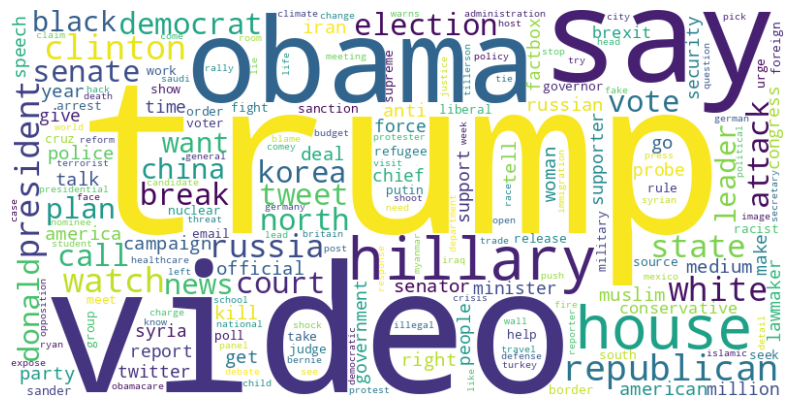

In [ ]:
# Wordcloud with most frequent words
wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(tfidf_dataset['proportion'])

# Display the word cloud
plt.figure(figsize=(10, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

#MACHINE LEARNING ANALYSIS

In [ ]:
# Define dependent and independent variable
X = df_news_copy['cleaned_text']
y = df_news_copy['type_news']

In [ ]:
# Transform list of cleaned text again in string
X = X.apply(lambda x: ' '.join(x))

In [ ]:
# Divide training and test set
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [ ]:
# Vectorization with TDFIDF
vectorizer = TfidfVectorizer()

x_train_vectorized = vectorizer.fit_transform(x_train)
x_test_vectorized = vectorizer.transform(x_test)

###Logistic Regression

In [ ]:
# Logistic Regression due to binary outcome
lr_model = LogisticRegression()

# Fit model on training data
lr_model.fit(x_train_vectorized, y_train)

# Fit model
y_pred = lr_model.predict(x_test_vectorized)

# Model metrics
print (classification_report(y_test, y_pred))

              precision    recall  f1-score   support

        fake       0.98      0.98      0.98      6870
        true       0.98      0.98      0.98      6347

    accuracy                           0.98     13217
   macro avg       0.98      0.98      0.98     13217
weighted avg       0.98      0.98      0.98     13217



The metrics of the logistic regression model show excellent performance:

-**Accuracy**: 0.98 means that the model correctly classifies 98% of the news in the test set.
-**Precision**: 0.98 for both classes, indicating that 98% of the news classified as "fake" and "true" are correct.
-**Recall**: 0.98 for both classes, meaning that the model correctly identifies 98% of the actual "fake" and "true" news.
-**F1-score**: 0.98, showing an excellent balance between precision and recall.

In [ ]:
# Find the top 20 features determining the classification
feature_names = vectorizer.get_feature_names_out()
sorted_coef_index = lr_model.coef_[0].argsort()

# Print the top 20 positive features
print("Top positive features:\n", feature_names[sorted_coef_index[-20:]])
# Print the top 20 negative features
print("Top negative features:\n", feature_names[sorted_coef_index[:20]])

Top positive features:
 ['kill' 'presidential' 'spokeswoman' 'militant' 'moscow' 'comment'
 'prosecutor' 'united' 'democratic' 'statement' 'spokesman'
 'representative' 'friday' 'minister' 'monday' 'thursday' 'tuesday'
 'washington' 'wednesday' 'reuters']
Top negative features:
 ['feature' 'image' 'hillary' 'america' 'century' 'american' 'entire'
 'actually' 'twitter' 'breitbart' 'terrorist' 'wouldn' 'morning' 'course'
 'report' 'taxpayer' 'explain' 'claim' 'terror' 'reason']


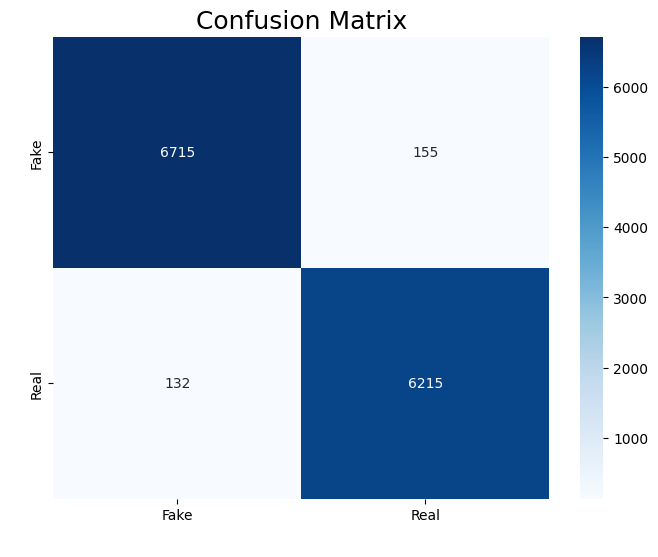

In [ ]:
# Confusion Matrix
conf_matrix = cm(y_test, y_pred)

# HeatMap
plt.figure(figsize=(8, 6))
# Removed the 'classes' parameter, and added labels using xticklabels and yticklabels
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=['Fake', 'Real'], yticklabels=['Fake', 'Real'])

plt.title("Confusion Matrix", fontsize = 18)
plt.xlabel(" ", fontsize = 14)
plt.ylabel(" ")
plt.show()

In [ ]:
# Save with pickle
with open('logistic_regression_model.pkl', 'wb') as file:
    pickle.dump(lr_model, file)

##Naive Bayes Model

In [ ]:
# Creation of the Naive Bayes model
naive_bayes_classifier = MultinomialNB()
naive_bayes_classifier.fit(x_train_vectorized, y_train)

# Model evaluation
y_pred = naive_bayes_classifier.predict(x_test_vectorized)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

        fake       0.93      0.91      0.92      6870
        true       0.91      0.92      0.91      6347

    accuracy                           0.92     13217
   macro avg       0.92      0.92      0.92     13217
weighted avg       0.92      0.92      0.92     13217



The Naive Bayes model also performed well but with slightly lower results compared to Logistic Regression:

- **Accuracy**: 0.92 the model correctly classified 92% of the articles in the test set.
- **Precision**: 0.93 for fake news and 0.91 for true news, showing the model was slightly better at correctly identifying fake news.
- **Recall**:0.91 for fake news and 93% for true news, showing that true news was more frequently identified correctly.
- **F1-Score**: 0.92 still a strong performance, but lower than Logistic Regression.


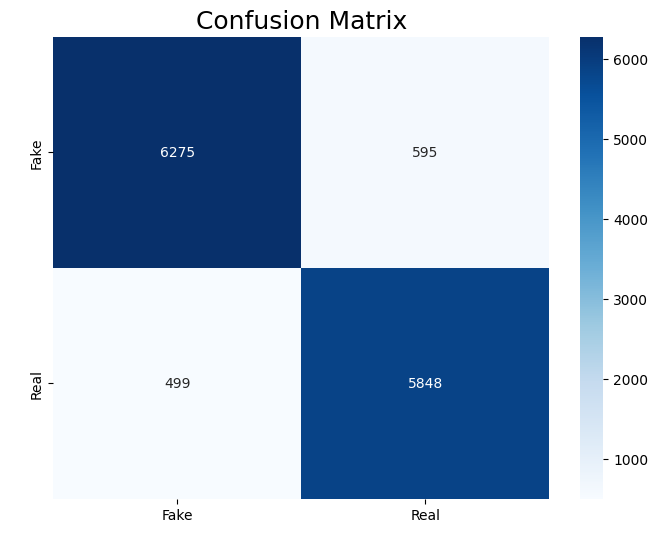

In [ ]:
# Confusion Matrix
conf_matrix = cm(y_test, y_pred)

# HeatMap
plt.figure(figsize=(8, 6))
# Removed the 'classes' parameter, and added labels using xticklabels and yticklabels
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=['Fake', 'Real'], yticklabels=['Fake', 'Real'])

plt.title("Confusion Matrix", fontsize = 18)
plt.xlabel(" ", fontsize = 14)
plt.ylabel(" ")
plt.show()

In [ ]:
# Save with pickle
with open('naive_bayes_model.pkl', 'wb') as file:
    pickle.dump(naive_bayes_classifier, file)

##Try models with unseen invented data

In [ ]:
# Create a text
unseen_text = """
In 2024, Donald Trump was elected President of the United States again, marking a notable moment in American political history.
"""

In [ ]:
# Cleaning with the function created above
unseen_text_cleaned = preprocess_text([unseen_text])

In [ ]:
unseen_text_cleaned

'donald elect president united state mark notable moment american political history'

In [ ]:
# Join the tokens into a single string
unseen_text_cleaned = ' '.join(unseen_text_cleaned[0])

In [ ]:
# Logistic regression
unseen_text_vectorized = vectorizer.transform([unseen_text_cleaned])
prediction = lr_model.predict(unseen_text_vectorized)
print(prediction)

['fake']


In [ ]:
# Naive Bayes
unseen_text_vectorized = vectorizer.transform([unseen_text_cleaned])
prediction = naive_bayes_classifier.predict(unseen_text_vectorized)
print(prediction)

['fake']
